In [50]:
import pandas as pd
import numpy as np


In [51]:
df = pd.read_csv("C:\\Users\\LENOVO\\Desktop\\Exam _ shafi\\heart_failure_clinical_records_dataset.csv.xls")

In [52]:
df.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

In [53]:
df[df.duplicated()]

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT


In [54]:
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [55]:
df["DEATH_EVENT"].value_counts()

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

In [56]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [57]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# x_train =scaler.fit_transform(x_train)
# x_test =scaler.fit_transform(x_test)



In [58]:
#scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train =scaler.fit_transform(x_train)
x_test =scaler.fit_transform(x_test)



In [59]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [60]:
y_pred= knn.predict(x_test)
y_pred

array([0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1])

In [61]:
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score
print(f"accuracy_score ={accuracy_score(y_test,y_pred)*100}")
print(f"f1_score ={f1_score(y_test,y_pred)*100}")
print(f"recall_score ={recall_score(y_test,y_pred)*100}")
print(f"precision_score ={precision_score(y_test,y_pred)*100}")

accuracy_score =70.0
f1_score =47.05882352941176
recall_score =32.0
precision_score =88.88888888888889


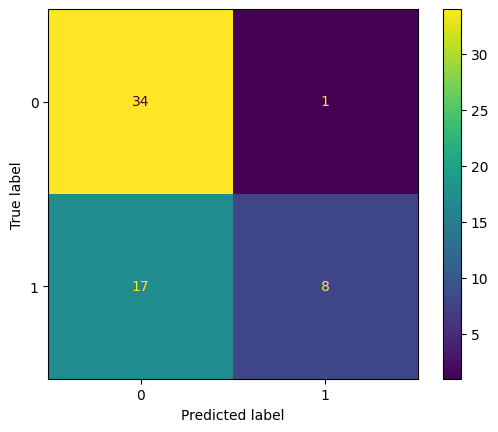

In [62]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)


In [63]:
from sklearn.gaussian_process import GaussianProcessClassifier
gb= GaussianProcessClassifier()
gb.fit(x_train,y_train)

,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ""1.0 * RBF(1.0)"" is used as default. Note thatthe kernel's hyperparameters are optimized during fitting. Also kernelcannot be a `CompoundKernel`.",None
,"optimizer optimizer: 'fmin_l_bfgs_b', callable or None, default='fmin_l_bfgs_b'Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func' is the objective function to be maximized, which # takes the hyperparameters theta as parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the 'L-BFGS-B' algorithm from scipy.optimize.minimizeis used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are:: 'fmin_l_bfgs_b'",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that n_restarts_optimizer=0 implies that onerun is performed.",0
,"max_iter_predict max_iter_predict: int, default=100The maximum number of iterations in Newton's method for approximatingthe posterior during predict. Smaller values will reduce computationtime at the cost of worse results.",100
,"warm_start warm_start: bool, default=FalseIf warm-starts are enabled, the solution of the last Newton iterationon the Laplace approximation of the posterior mode is used asinitialization for the next call of _posterior_mode(). This can speedup convergence when _posterior_mode is called several times on similarproblems as in hyperparameter optimization. See :term:`the Glossary`.",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None
,"multi_class multi_class: {'one_vs_rest', 'one_vs_one'}, default='one_vs_rest'Specifies how multi-class classification problems are handled.Supported are 'one_vs_rest' and 'one_vs_one'. In 'one_vs_rest',one binary Gaussian process classifier is fitted for each class, whichis trained to separate this class from the rest. In 'one_vs_one', onebinary Gaussian process classifier is fitted for each pair of classes,which is trained to separate these two classes. The predictions ofthese binary predictors are combined into multi-class predictions.Note that 'one_vs_one' does not support predicting probabilityestimates.",'one_vs_rest'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the specifiedmulticlass problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [64]:
y_pred1 = gb.predict(x_test)
y_pred1

array([0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1])

In [65]:
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score
print(f"accuracy_score ={accuracy_score(y_test,y_pred1)*100}")
print(f"f1_score ={f1_score(y_test,y_pred1)*100}")
print(f"recall_score ={recall_score(y_test,y_pred1)*100}")
print(f"precision_score ={precision_score(y_test,y_pred1)*100}")

accuracy_score =73.33333333333333
f1_score =52.94117647058824
recall_score =36.0
precision_score =100.0


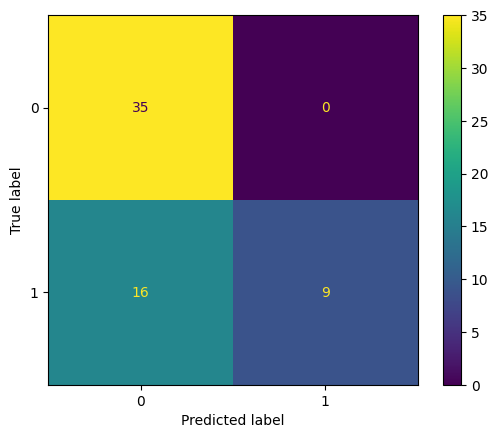

In [66]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test,y_pred1)


In [67]:
#decision tree
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion="entropy",max_depth=3)
model.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [68]:
y_pred_dec = model.predict(x_test)

In [69]:
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score
print(f"accuracy_score ={accuracy_score(y_test,y_pred_dec)*100}")
print(f"f1_score ={f1_score(y_test,y_pred_dec)*100}")
print(f"recall_score ={recall_score(y_test,y_pred_dec)*100}")
print(f"precision_score ={precision_score(y_test,y_pred_dec)*100}")

accuracy_score =75.0
f1_score =61.53846153846154
recall_score =48.0
precision_score =85.71428571428571


In [70]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,f1_score

models = [DecisionTreeClassifier,KNeighborsClassifier,GaussianNB]

for model in models:

    md = model()
    md.fit(x_train,y_train)
    y_pred= md.predict(x_test)
    print("=============",model,"============")
    print(f"accuracy_score {accuracy_score(y_pred,y_test)*100}")
    print(f"f1_score {f1_score(y_pred,y_test)*100}")

============= <class 'sklearn.tree._classes.DecisionTreeClassifier'> ============
accuracy_score 66.66666666666666
f1_score 56.52173913043478
============= <class 'sklearn.neighbors._classification.KNeighborsClassifier'> ============
accuracy_score 68.33333333333333
f1_score 38.70967741935484
============= <class 'sklearn.naive_bayes.GaussianNB'> ============
accuracy_score 71.66666666666667
f1_score 51.42857142857142


In [71]:
from imblearn.over_sampling import SMOTE

sm= SMOTE(random_state=42)
x_train_smote,y_train_smote = sm.fit_resample(x_train,y_train)

In [72]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=11)
rf.fit(x_train_smote,y_train_smote)
y_pred_rf = rf.predict(x_test)
print(f"random forest")
print(f"accuracy_score {accuracy_score(y_pred_rf,y_test)*100}")
print(f"f1_score {f1_score(y_pred_rf,y_test)*100}")


random forest
accuracy_score 73.33333333333333
f1_score 65.21739130434783
